In [11]:
!pip install ultralytics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 915.2/915.2 kB 23.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 2.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 92.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 71.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 51.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 2.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 2.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 11.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 6.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 4.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 73.2 MB/s eta 0:00:00
  Attempting uninstall: nvidia-nvjitlink-cu12
    Found existing installation: nvidia-nvjitlink-cu12 12.5.82
    Uninstall

In [12]:
import os
import shutil
from ultralytics import YOLO

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


In [13]:
import os

# Step 1: Install the Kaggle library
!pip install kaggle

# Step 2: Upload kaggle.json to Colab
from google.colab import files
files.upload()

# Step 3: Configure Kaggle API key
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

# Step 4: Set dataset path and download dataset
# Replace 'your-dataset-path' with the actual path of the dataset on Kaggle
DATASET_PATH = 'saisirishan/indian-vehicle-dataset'  # Example dataset path

# Download the dataset
!kaggle datasets download -d {DATASET_PATH}

# Step 5: Unzip the dataset
import zipfile
import glob

for file in glob.glob("*.zip"):
    with zipfile.ZipFile(file, 'r') as zip_ref:
        zip_ref.extractall("./dataset")

def unzip_data(directory="."):
    """Unzips all zip files in the specified directory."""
    for file in glob.glob(os.path.join(directory, "*.zip")):
        with zipfile.ZipFile(file, 'r') as zip_ref:
            zip_ref.extractall(directory)
        print(f"Extracted: {file}")

unzip_data("./dataset")

print("Dataset downloaded and extracted successfully!")


Saving kaggle (1).json to kaggle (1).json
cp: cannot stat 'kaggle.json': No such file or directory
chmod: cannot access '/root/.kaggle/kaggle.json': No such file or directory
Dataset URL: https://www.kaggle.com/datasets/saisirishan/indian-vehicle-dataset
License(s): unknown
 90% 161M/178M [00:01<00:00, 111MB/s]
100% 178M/178M [00:01<00:00, 114MB/s]
Dataset downloaded and extracted successfully!


In [14]:
from ultralytics import YOLO

In [15]:
model = YOLO("/content/yolo11n.pt")

100%|██████████| 5.35M/5.35M [00:00<00:00, 87.2MB/s]


In [17]:
import locale
def getpreferredencoding(do_setlocale = True):
    return "UTF-8"
locale.getpreferredencoding = getpreferredencoding
!pip install pytesseract

In [18]:
import os
import cv2
import numpy as np
import pandas as pd
import tensorflow as tf
import pytesseract as pt
import plotly.express as px
import matplotlib.pyplot as plt
import xml.etree.ElementTree as xet

from glob import glob
from skimage import io
from shutil import copy
from tensorflow.keras.models import Model
from tensorflow.keras.callbacks import TensorBoard
from sklearn.model_selection import train_test_split
from tensorflow.keras.applications import InceptionResNetV2
from tensorflow.keras.layers import Dense, Dropout, Flatten, Input
from tensorflow.keras.preprocessing.image import load_img, img_to_array

In [19]:
path = glob('/content/dataset/google_images/*.xml')
print(len(path))


labels_dict = dict(filepath=[],xmin=[],xmax=[],ymin=[],ymax=[])

for filename in path:

    info = xet.parse(filename)
    root = info.getroot()
    member_object = root.find('object')
    labels_info = member_object.find('bndbox')
    xmin = int(labels_info.find('xmin').text)
    xmax = int(labels_info.find('xmax').text)
    ymin = int(labels_info.find('ymin').text)
    ymax = int(labels_info.find('ymax').text)

    labels_dict['filepath'].append(filename)
    labels_dict['xmin'].append(xmin)
    labels_dict['xmax'].append(xmax)
    labels_dict['ymin'].append(ymin)
    labels_dict['ymax'].append(ymax)

440


In [20]:
new_paths = glob('/content/dataset/State-wise_OLX/*/*.xml')
print(len(new_paths))


new_labels_dict = dict(filepath=[],xmin=[],xmax=[],ymin=[],ymax=[])

for filename in new_paths:

    info = xet.parse(filename)
    root = info.getroot()
    member_object = root.find('object')
    labels_info = member_object.find('bndbox')
    xmin = int(labels_info.find('xmin').text)
    xmax = int(labels_info.find('xmax').text)
    ymin = int(labels_info.find('ymin').text)
    ymax = int(labels_info.find('ymax').text)

    new_labels_dict['filepath'].append(filename)
    new_labels_dict['xmin'].append(xmin)
    new_labels_dict['xmax'].append(xmax)
    new_labels_dict['ymin'].append(ymin)
    new_labels_dict['ymax'].append(ymax)

603


In [21]:
df = pd.DataFrame(labels_dict)
df.to_csv('labels.csv',index=False)
df.head()

,filepath,xmin,xmax,ymin,ymax
0,/content/dataset/google_images/65e2825e-943f-4...,134,252,259,299
1,/content/dataset/google_images/f94e9bcf-ec4a-4...,128,243,299,329
2,/content/dataset/google_images/ed6ee171-691a-4...,124,400,270,331
3,/content/dataset/google_images/car-wbs-TN21BC6...,42,146,120,146
4,/content/dataset/google_images/5231116f-7a07-4...,187,351,342,384


In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 440 entries, 0 to 439
Data columns (total 5 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   filepath  440 non-null    object
 1   xmin      440 non-null    int64 
 2   xmax      440 non-null    int64 
 3   ymin      440 non-null    int64 
 4   ymax      440 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 17.3+ KB


In [12]:
new_df = pd.DataFrame(new_labels_dict)
new_df.to_csv('new_labels.csv',index=False)
new_df.head()

,filepath,xmin,xmax,ymin,ymax
0,/content/dataset/State-wise_OLX/MZ/MZ1.xml,119,181,98,112
1,/content/dataset/State-wise_OLX/MP/MP6.xml,91,178,239,256
2,/content/dataset/State-wise_OLX/MP/MP10.xml,95,184,265,284
3,/content/dataset/State-wise_OLX/MP/MP1.xml,90,171,269,287
4,/content/dataset/State-wise_OLX/MP/MP5.xml,101,171,230,244


In [13]:
new_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 603 entries, 0 to 602
Data columns (total 5 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   filepath  603 non-null    object
 1   xmin      603 non-null    int64 
 2   xmax      603 non-null    int64 
 3   ymin      603 non-null    int64 
 4   ymax      603 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 23.7+ KB


In [14]:
def parsing(path):
    parser = xet.parse(path).getroot()
    name = parser.find('filename').text
    filename = f'/content/dataset/google_images/{name}'

    # width and height
    parser_size = parser.find('size')
    width = int(parser_size.find('width').text)
    height = int(parser_size.find('height').text)

    return filename, width, height

df[['filename','width','height']] = df['filepath'].apply(parsing).apply(pd.Series)
df.head()

,filepath,xmin,xmax,ymin,ymax,filename,width,height
0,/content/dataset/google_images/e82fc408-a209-4...,309,442,303,356,/content/dataset/google_images/e82fc408-a209-4...,540,720
1,/content/dataset/google_images/12e26859-89e0-4...,155,286,194,232,/content/dataset/google_images/12e26859-89e0-4...,700,466
2,/content/dataset/google_images/f20708c6-14cd-4...,153,412,230,296,/content/dataset/google_images/f20708c6-14cd-4...,600,400
3,/content/dataset/google_images/8b9e7112-9149-4...,231,431,252,308,/content/dataset/google_images/8b9e7112-9149-4...,551,455
4,/content/dataset/google_images/4434b404-dd10-4...,140,306,157,208,/content/dataset/google_images/4434b404-dd10-4...,397,247


In [15]:
def newparsing(path):
    parser = xet.parse(path).getroot()
    name = parser.find('filename').text
    filename = f'/content/dataset/State-wise_OLX/{name[:2]}/{name}'

    # width and height
    parser_size = parser.find('size')
    width = int(parser_size.find('width').text)
    height = int(parser_size.find('height').text)

    return filename, width, height

new_df[['filename','width','height']] = new_df['filepath'].apply(newparsing).apply(pd.Series)
new_df.head()

,filepath,xmin,xmax,ymin,ymax,filename,width,height
0,/content/dataset/State-wise_OLX/MZ/MZ1.xml,119,181,98,112,/content/dataset/State-wise_OLX/MZ/MZ1.jpg,272,125
1,/content/dataset/State-wise_OLX/MP/MP6.xml,91,178,239,256,/content/dataset/State-wise_OLX/MP/MP6.jpg,272,363
2,/content/dataset/State-wise_OLX/MP/MP10.xml,95,184,265,284,/content/dataset/State-wise_OLX/MP/MP10.jpg,272,363
3,/content/dataset/State-wise_OLX/MP/MP1.xml,90,171,269,287,/content/dataset/State-wise_OLX/MP/MP1.jpg,269,436
4,/content/dataset/State-wise_OLX/MP/MP5.xml,101,171,230,244,/content/dataset/State-wise_OLX/MP/MP5.jpg,272,363


In [16]:
# center_x, center_y, width , height
df['center_x'] = (df['xmax'] + df['xmin'])/(2*df['width'])
df['center_y'] = (df['ymax'] + df['ymin'])/(2*df['height'])

df['bb_width'] = (df['xmax'] - df['xmin'])/df['width']
df['bb_height'] = (df['ymax'] - df['ymin'])/df['height']
df.head()

,filepath,xmin,xmax,ymin,ymax,filename,width,height,center_x,center_y,bb_width,bb_height
0,/content/dataset/google_images/e82fc408-a209-4...,309,442,303,356,/content/dataset/google_images/e82fc408-a209-4...,540,720,0.695370,0.457639,0.246296,0.073611
1,/content/dataset/google_images/12e26859-89e0-4...,155,286,194,232,/content/dataset/google_images/12e26859-89e0-4...,700,466,0.315000,0.457082,0.187143,0.081545
2,/content/dataset/google_images/f20708c6-14cd-4...,153,412,230,296,/content/dataset/google_images/f20708c6-14cd-4...,600,400,0.470833,0.657500,0.431667,0.165000
3,/content/dataset/google_images/8b9e7112-9149-4...,231,431,252,308,/content/dataset/google_images/8b9e7112-9149-4...,551,455,0.600726,0.615385,0.362976,0.123077
4,/content/dataset/google_images/4434b404-dd10-4...,140,306,157,208,/content/dataset/google_images/4434b404-dd10-4...,397,247,0.561713,0.738866,0.418136,0.206478


In [17]:
# center_x, center_y, width , height
new_df['center_x'] = (new_df['xmax'] + new_df['xmin'])/(2*new_df['width'])
new_df['center_y'] = (new_df['ymax'] + new_df['ymin'])/(2*new_df['height'])

new_df['bb_width'] = (new_df['xmax'] - new_df['xmin'])/new_df['width']
new_df['bb_height'] = (new_df['ymax'] - new_df['ymin'])/new_df['height']
new_df.head()

,filepath,xmin,xmax,ymin,ymax,filename,width,height,center_x,center_y,bb_width,bb_height
0,/content/dataset/State-wise_OLX/MZ/MZ1.xml,119,181,98,112,/content/dataset/State-wise_OLX/MZ/MZ1.jpg,272,125,0.551471,0.840000,0.227941,0.112000
1,/content/dataset/State-wise_OLX/MP/MP6.xml,91,178,239,256,/content/dataset/State-wise_OLX/MP/MP6.jpg,272,363,0.494485,0.681818,0.319853,0.046832
2,/content/dataset/State-wise_OLX/MP/MP10.xml,95,184,265,284,/content/dataset/State-wise_OLX/MP/MP10.jpg,272,363,0.512868,0.756198,0.327206,0.052342
3,/content/dataset/State-wise_OLX/MP/MP1.xml,90,171,269,287,/content/dataset/State-wise_OLX/MP/MP1.jpg,269,436,0.485130,0.637615,0.301115,0.041284
4,/content/dataset/State-wise_OLX/MP/MP5.xml,101,171,230,244,/content/dataset/State-wise_OLX/MP/MP5.jpg,272,363,0.500000,0.652893,0.257353,0.038567


In [18]:
mkdir /content/data_images/


In [19]:
import os

os.makedirs("/content/data_images/train", exist_ok=True)  # Create train directory
os.makedirs("/content/data_images/test", exist_ok=True)  # Create test directory

In [20]:
new_df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 603 entries, 0 to 602
Data columns (total 12 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   filepath   603 non-null    object 
 1   xmin       603 non-null    int64  
 2   xmax       603 non-null    int64  
 3   ymin       603 non-null    int64  
 4   ymax       603 non-null    int64  
 5   filename   603 non-null    object 
 6   width      603 non-null    int64  
 7   height     603 non-null    int64  
 8   center_x   603 non-null    float64
 9   center_y   603 non-null    float64
 10  bb_width   603 non-null    float64
 11  bb_height  603 non-null    float64
dtypes: float64(4), int64(6), object(2)
memory usage: 56.7+ KB


In [21]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 440 entries, 0 to 439
Data columns (total 12 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   filepath   440 non-null    object 
 1   xmin       440 non-null    int64  
 2   xmax       440 non-null    int64  
 3   ymin       440 non-null    int64  
 4   ymax       440 non-null    int64  
 5   filename   440 non-null    object 
 6   width      440 non-null    int64  
 7   height     440 non-null    int64  
 8   center_x   440 non-null    float64
 9   center_y   440 non-null    float64
 10  bb_width   440 non-null    float64
 11  bb_height  440 non-null    float64
dtypes: float64(4), int64(6), object(2)
memory usage: 41.4+ KB


In [22]:
data = pd.concat([df,new_df]).sample(frac=1).reset_index(drop=True)
data.head()

,filepath,xmin,xmax,ymin,ymax,filename,width,height,center_x,center_y,bb_width,bb_height
0,/content/dataset/State-wise_OLX/JK/JK29.xml,70,172,333,358,/content/dataset/State-wise_OLX/JK/JK29.jpg,272,604,0.444853,0.572020,0.375000,0.041391
1,/content/dataset/State-wise_OLX/PY/PY12.xml,119,180,163,183,/content/dataset/State-wise_OLX/PY/PY12.jpg,272,204,0.549632,0.848039,0.224265,0.098039
2,/content/dataset/State-wise_OLX/ML/ML28.xml,72,158,234,255,/content/dataset/State-wise_OLX/ML/ML28.jpg,272,363,0.422794,0.673554,0.316176,0.057851
3,/content/dataset/State-wise_OLX/CH/CH5.xml,112,178,171,185,/content/dataset/State-wise_OLX/CH/CH5.jpg,272,204,0.533088,0.872549,0.242647,0.068627
4,/content/dataset/State-wise_OLX/DL/DL10.xml,98,161,215,228,/content/dataset/State-wise_OLX/DL/DL10.jpg,272,363,0.476103,0.610193,0.231618,0.035813


In [23]:
### split the data into train and test
df_train = data.iloc[:700]
df_test = data.iloc[700:]

In [24]:
train_folder = '/content/data_images/train'

values = df_train[['filename','center_x','center_y','bb_width','bb_height']].values
for fname, x,y, w, h in values:
    try:
        image_name = os.path.split(fname)[-1]
        txt_name = os.path.splitext(image_name)[0]

        dst_image_path = os.path.join(train_folder,image_name)
        dst_label_file = os.path.join(train_folder,txt_name+'.txt')

        # copy each image into the folder
        copy(fname,dst_image_path)

        # generate .txt which has label info
        label_txt = f'0 {x} {y} {w} {h}'
        with open(dst_label_file,mode='w') as f:
            f.write(label_txt)

            f.close()
    except:
        print(fname)

/content/dataset/State-wise_OLX/MH/MH5.jpg
/content/dataset/State-wise_OLX/NL/NL1.jpg


In [25]:
test_folder = '/content/data_images/test'

values = df_test[['filename','center_x','center_y','bb_width','bb_height']].values
for fname, x,y, w, h in values:
    try:
        image_name = os.path.split(fname)[-1]
        txt_name = os.path.splitext(image_name)[0]

        dst_image_path = os.path.join(test_folder,image_name)
        dst_label_file = os.path.join(test_folder,txt_name+'.txt')

        # copy each image into the folder
        copy(fname,dst_image_path)

        # generate .txt which has label info
        label_txt = f'0 {x} {y} {w} {h}'
        with open(dst_label_file,mode='w') as f:
            f.write(label_txt)

            f.close()
    except:
        print(fname)

In [26]:
f = open("/content/data.yaml", "w")

f.write('''train: /content/data_images/train
val: /content/data_images/test
nc: 1
names: [
    'license_plate'
]''')

f.close()

In [27]:
model = YOLO("yolo11n.pt")

In [28]:
!yolo task=detect mode=train epochs=50 batch=16 plots=True model='/content/yolo11n.pt' data='/content/data.yaml'


Ultralytics 8.3.76 🚀 Python-3.11.11 torch-2.5.1+cpu CPU (Intel Xeon 2.00GHz)
engine/trainer: task=detect, mode=train, model=/content/yolo11n.pt, data=/content/data.yaml, epochs=50, time=None, patience=100, batch=16, imgsz=640, save=True, save_period=-1, cache=False, device=None, workers=8, project=None, name=train, exist_ok=False, pretrained=True, optimizer=auto, verbose=True, seed=0, deterministic=True, single_cls=False, rect=False, cos_lr=False, close_mosaic=10, resume=False, amp=True, fraction=1.0, profile=False, freeze=None, multi_scale=False, overlap_mask=True, mask_ratio=4, dropout=0.0, val=True, split=val, save_json=False, save_hybrid=False, conf=None, iou=0.7, max_det=300, half=False, dnn=False, plots=True, source=None, vid_stride=1, stream_buffer=False, visualize=False, augment=False, agnostic_nms=False, classes=None, retina_masks=False, embed=None, show=False, save_frames=False, save_txt=False, save_conf=False, save_crop=False, show_labels=True, show_conf=True, show_boxes=Tru

In [32]:
#Validation
!yolo task=detect mode=val model='/content/runs/detect/train/weights/best.pt' data='/content/data.yaml' save_json=True


Ultralytics 8.3.76 🚀 Python-3.11.11 torch-2.5.1+cpu CPU (Intel Xeon 2.00GHz)
YOLO11n summary (fused): 100 layers, 2,582,347 parameters, 0 gradients, 6.3 GFLOPs
val: Scanning /content/data_images/test.cache... 343 images, 0 backgrounds, 0 corrupt: 100% 343/343 [00:00<?, ?it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% 22/22 [00:24<00:00,  1.10s/it]
                   all        343        343      0.988      0.994      0.994      0.858
Speed: 1.1ms preprocess, 62.0ms inference, 0.0ms loss, 0.4ms postprocess per image
Saving runs/detect/val/predictions.json...
Results saved to runs/detect/val
💡 Learn more at https://docs.ultralytics.com/modes/val


#Train Metrics

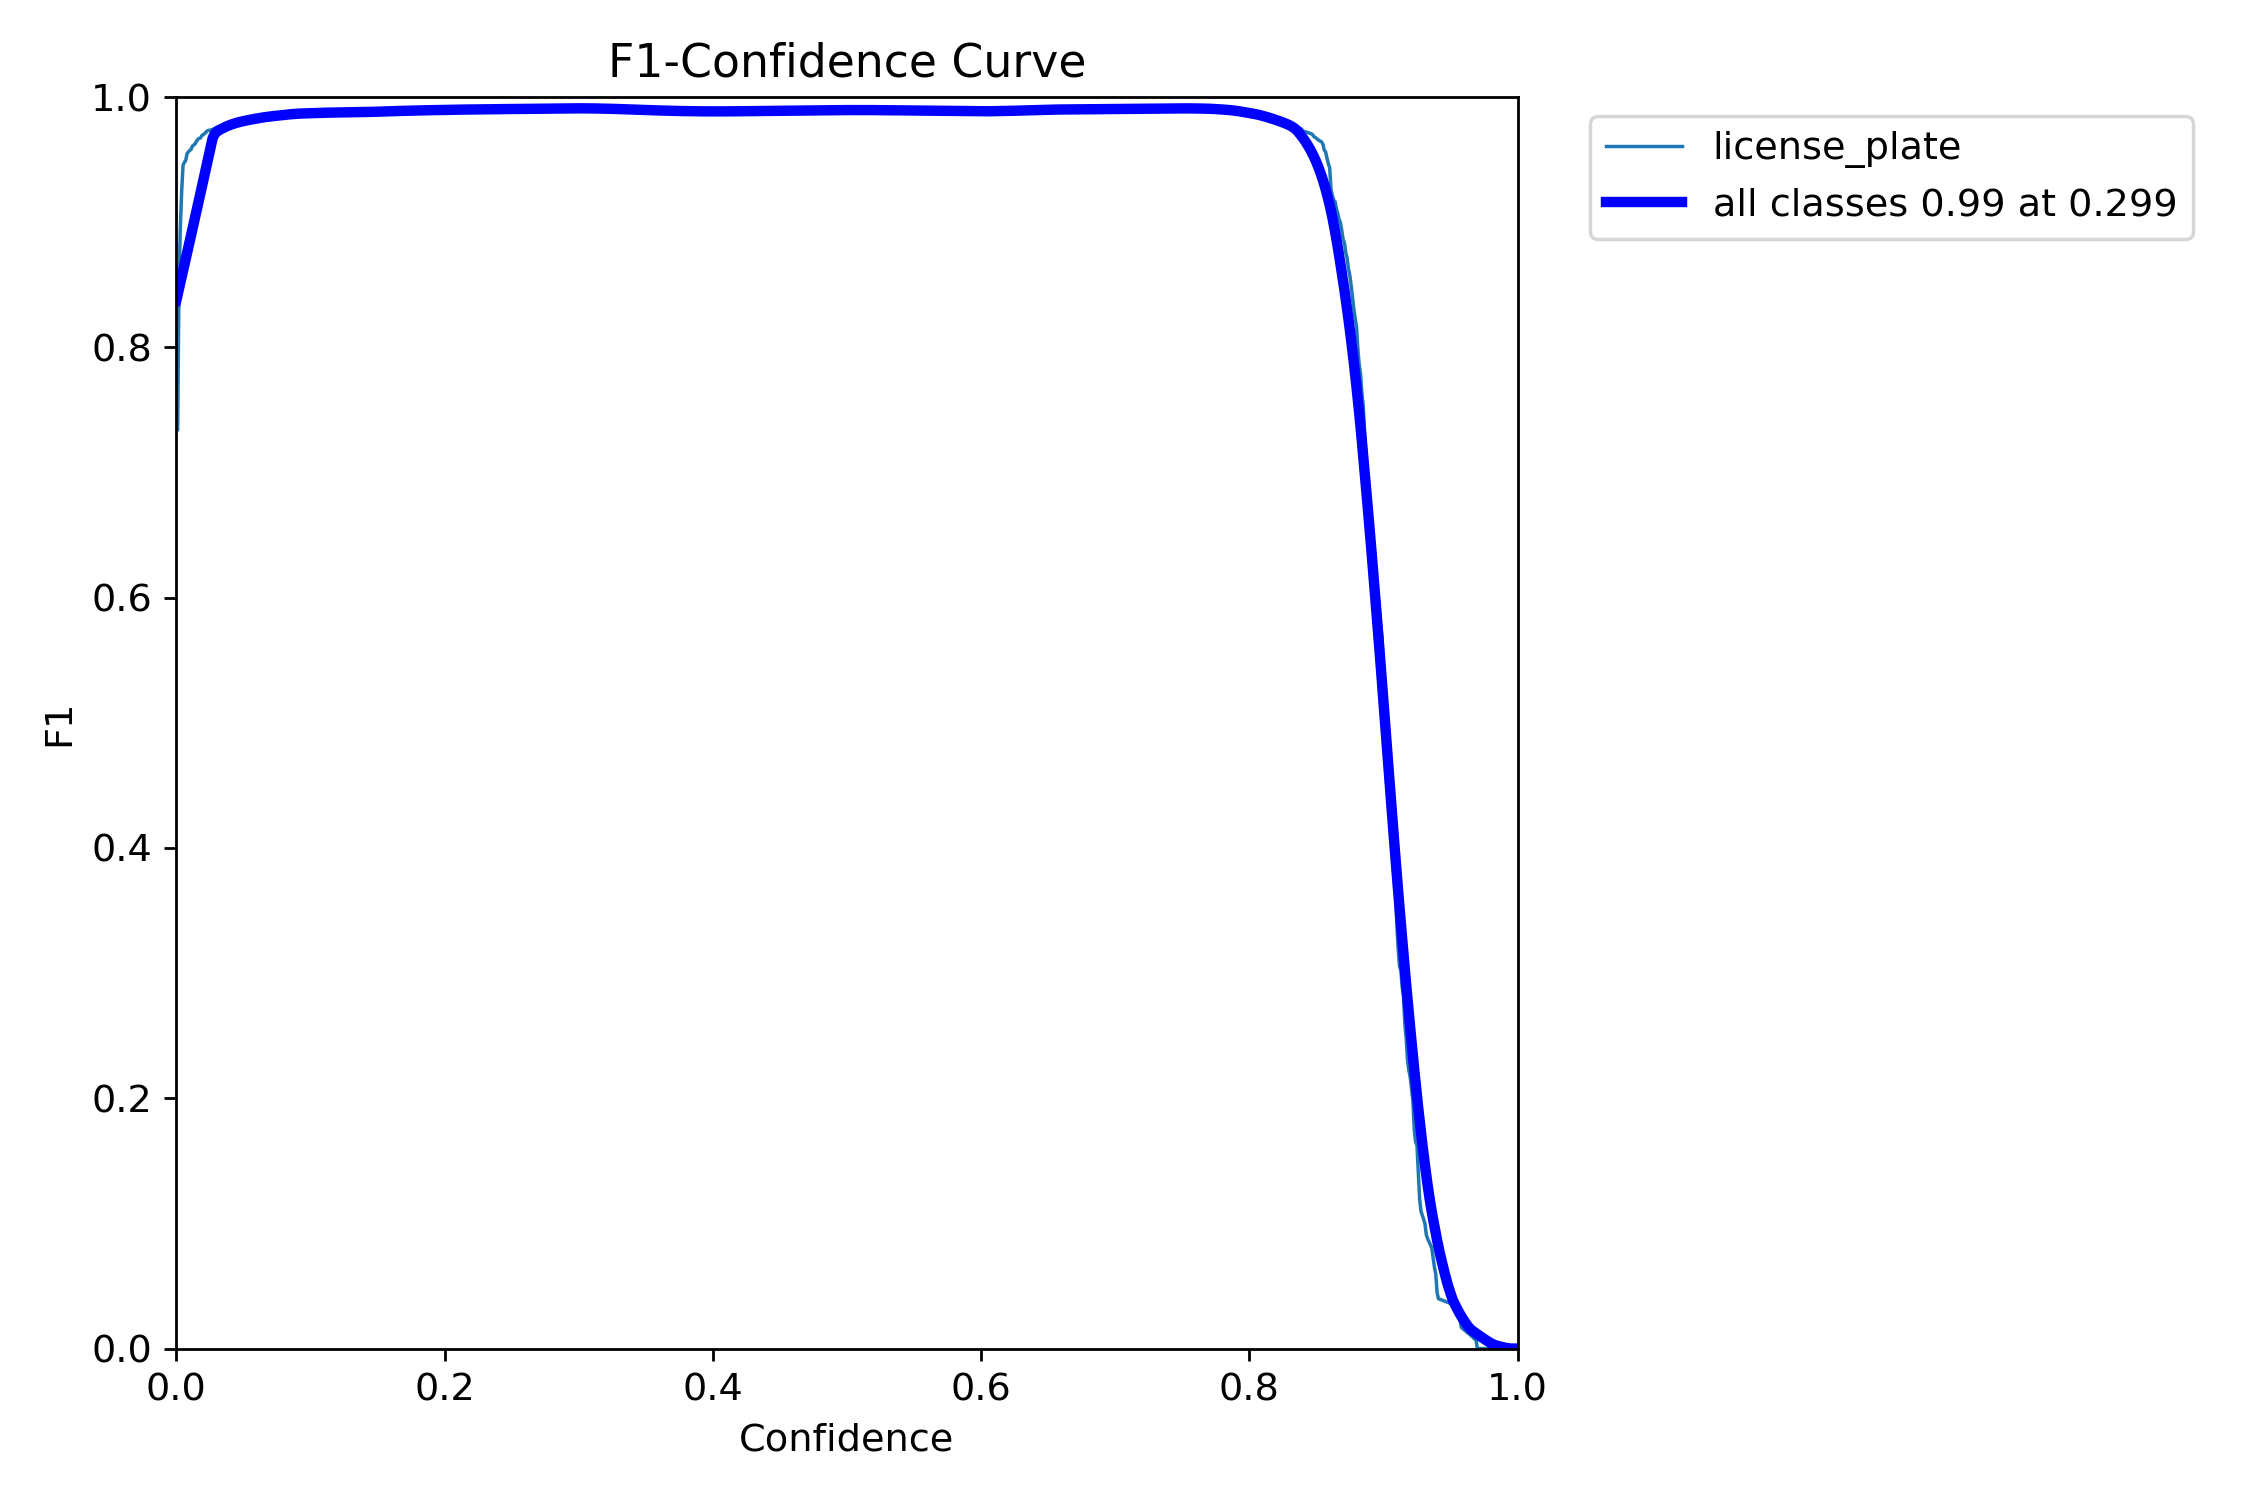

In [4]:
from IPython.display import Image
Image(filename='/content/F1_curve.png')

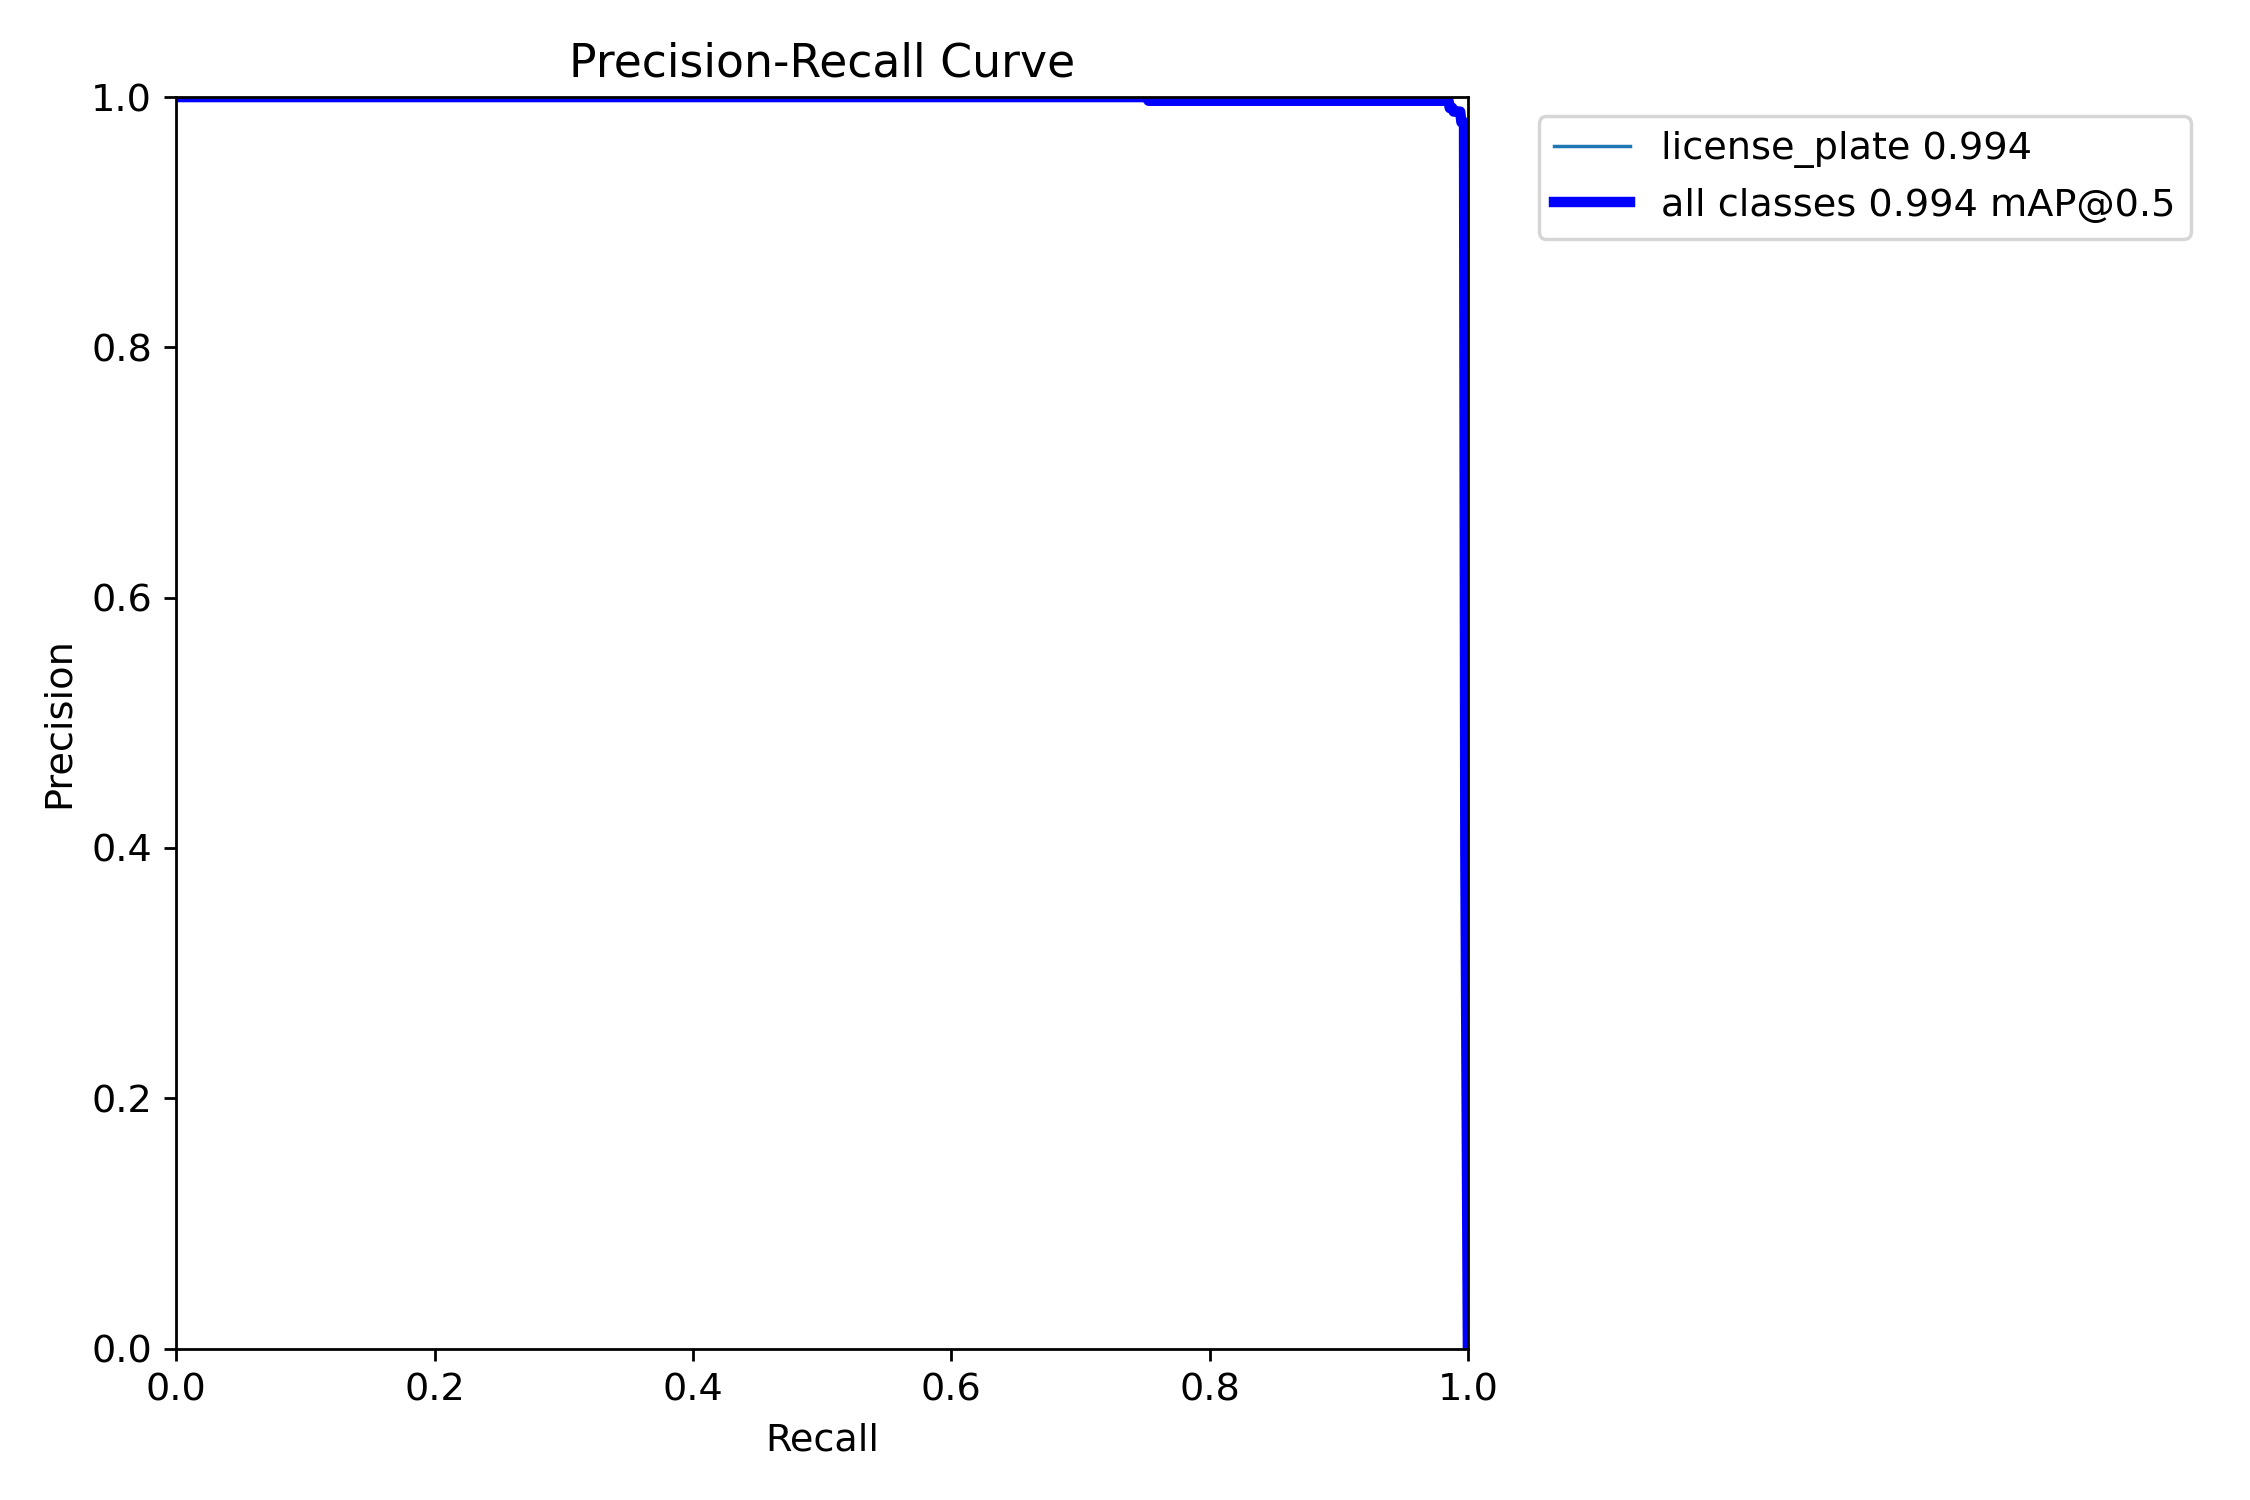

In [5]:
Image(filename='/content/PR_curve.png')

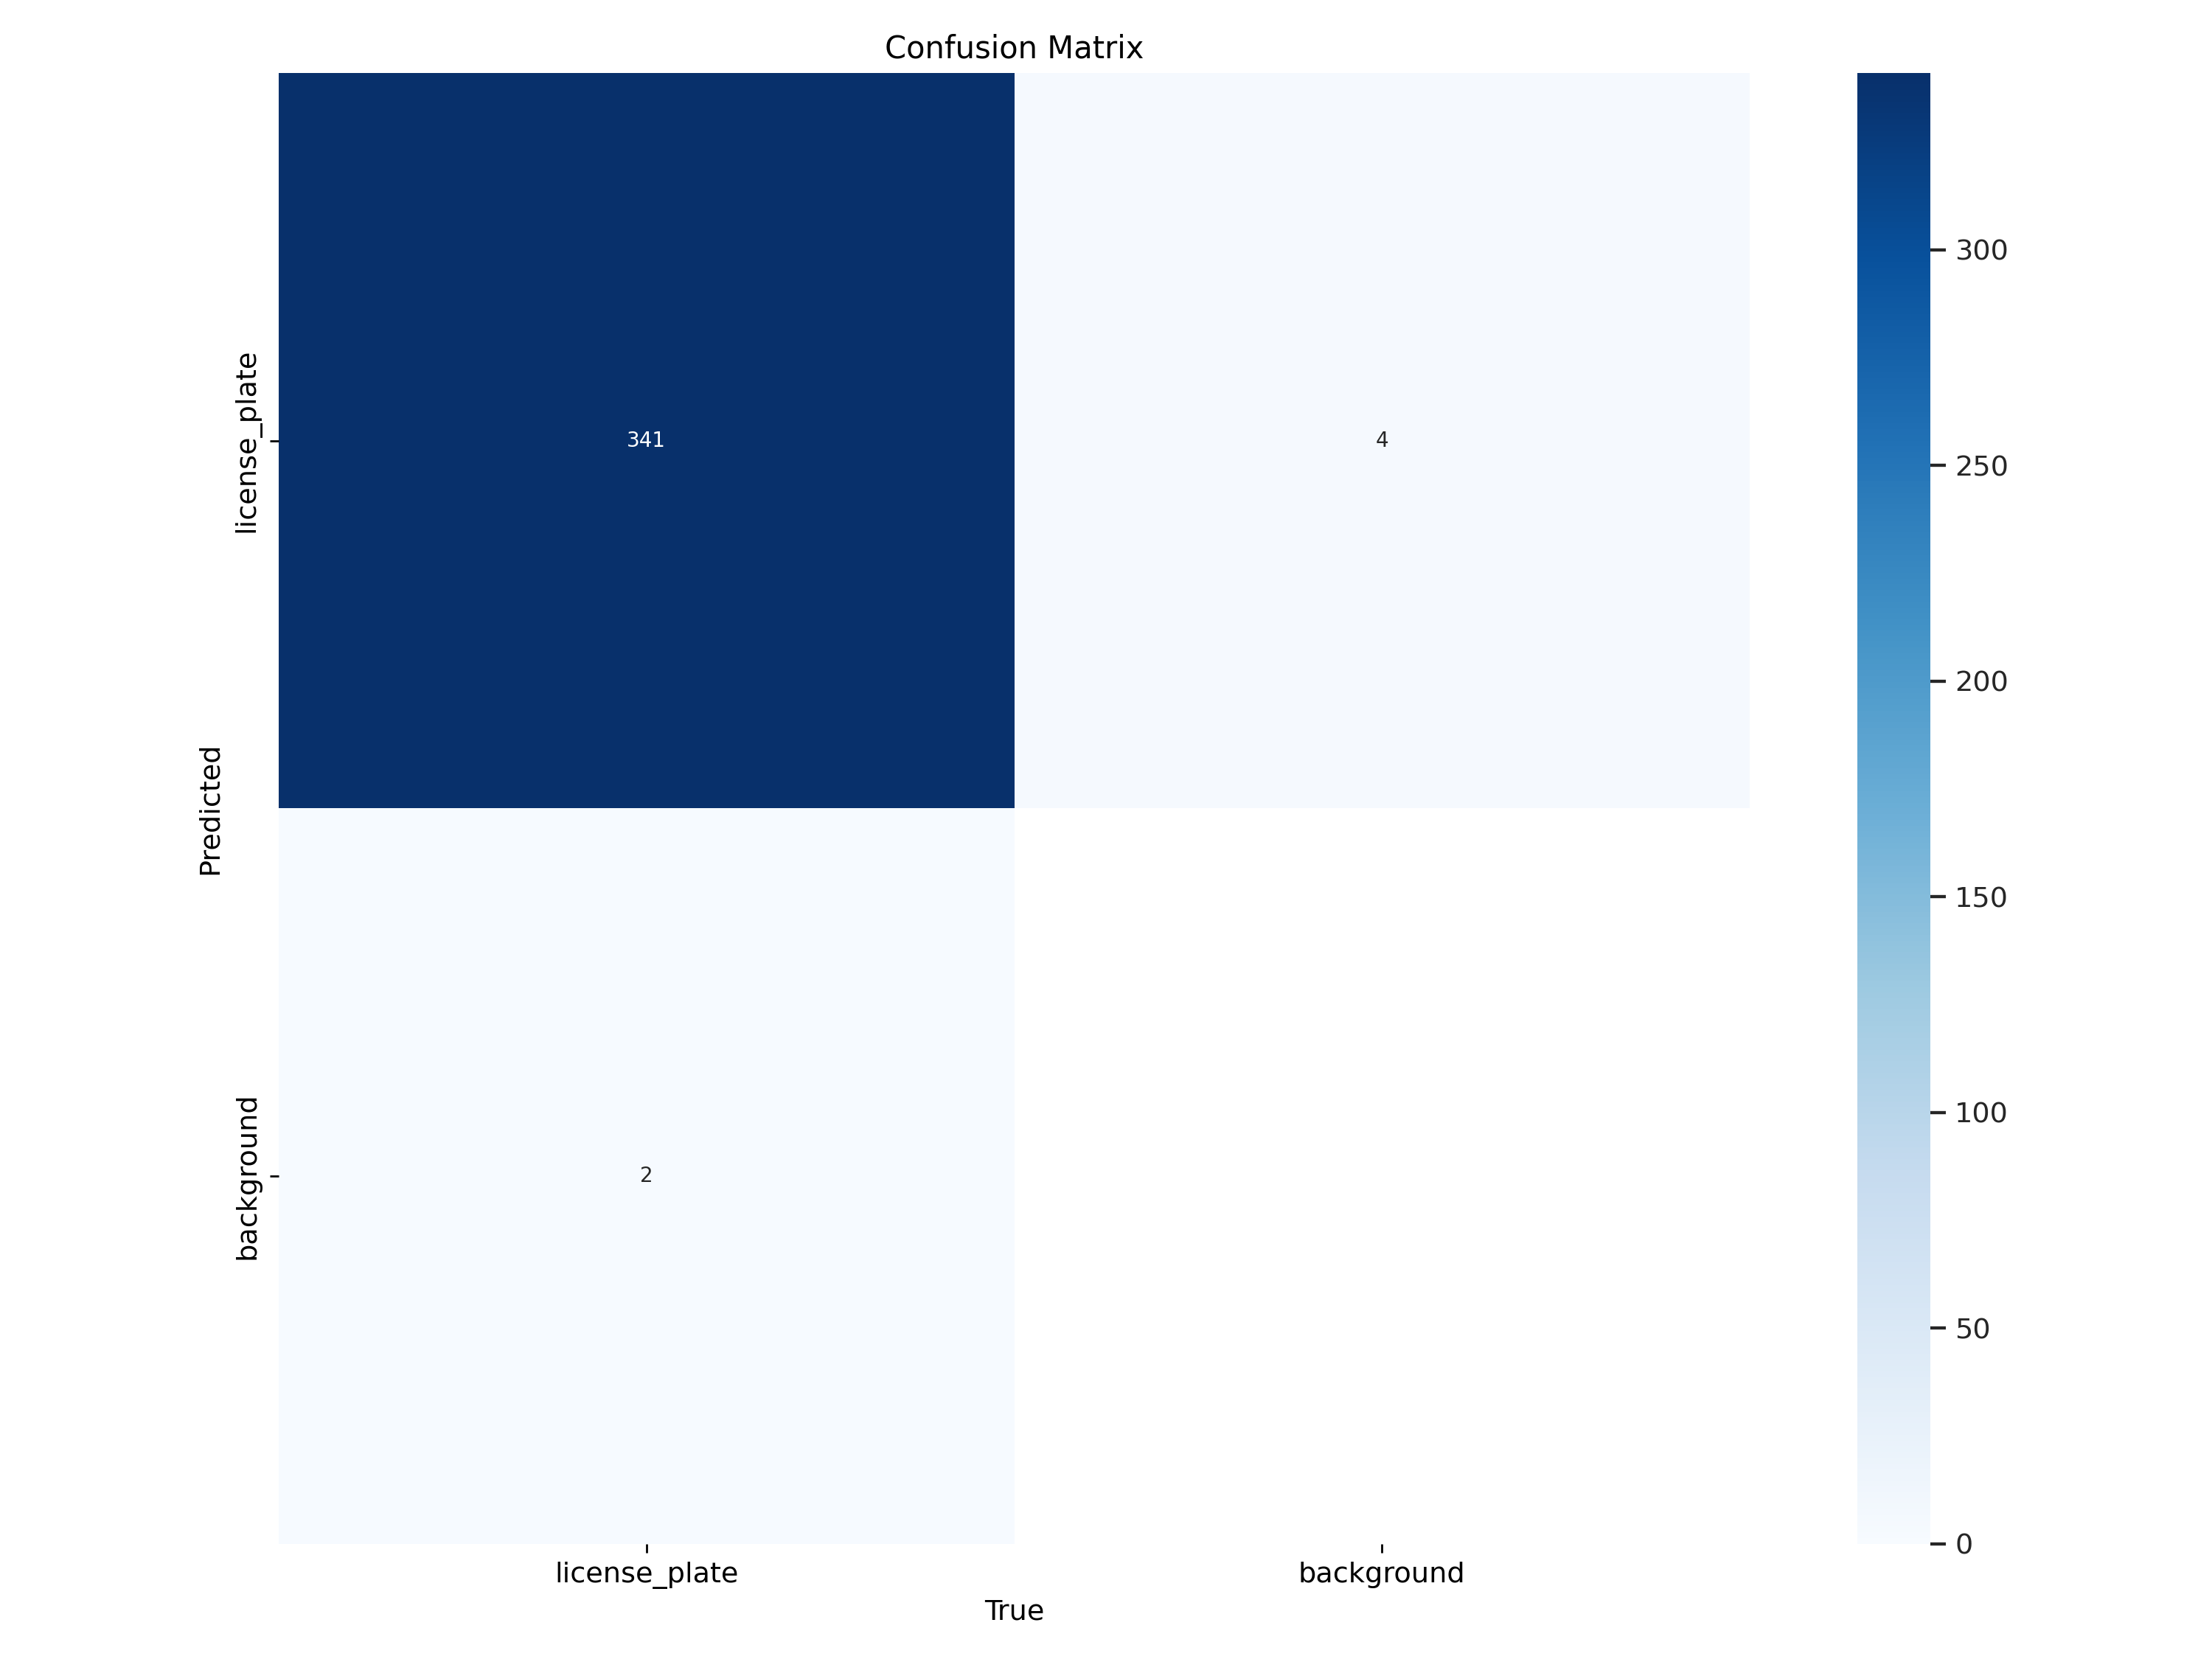

In [6]:
Image(filename='/content/confusion_matrix.png')

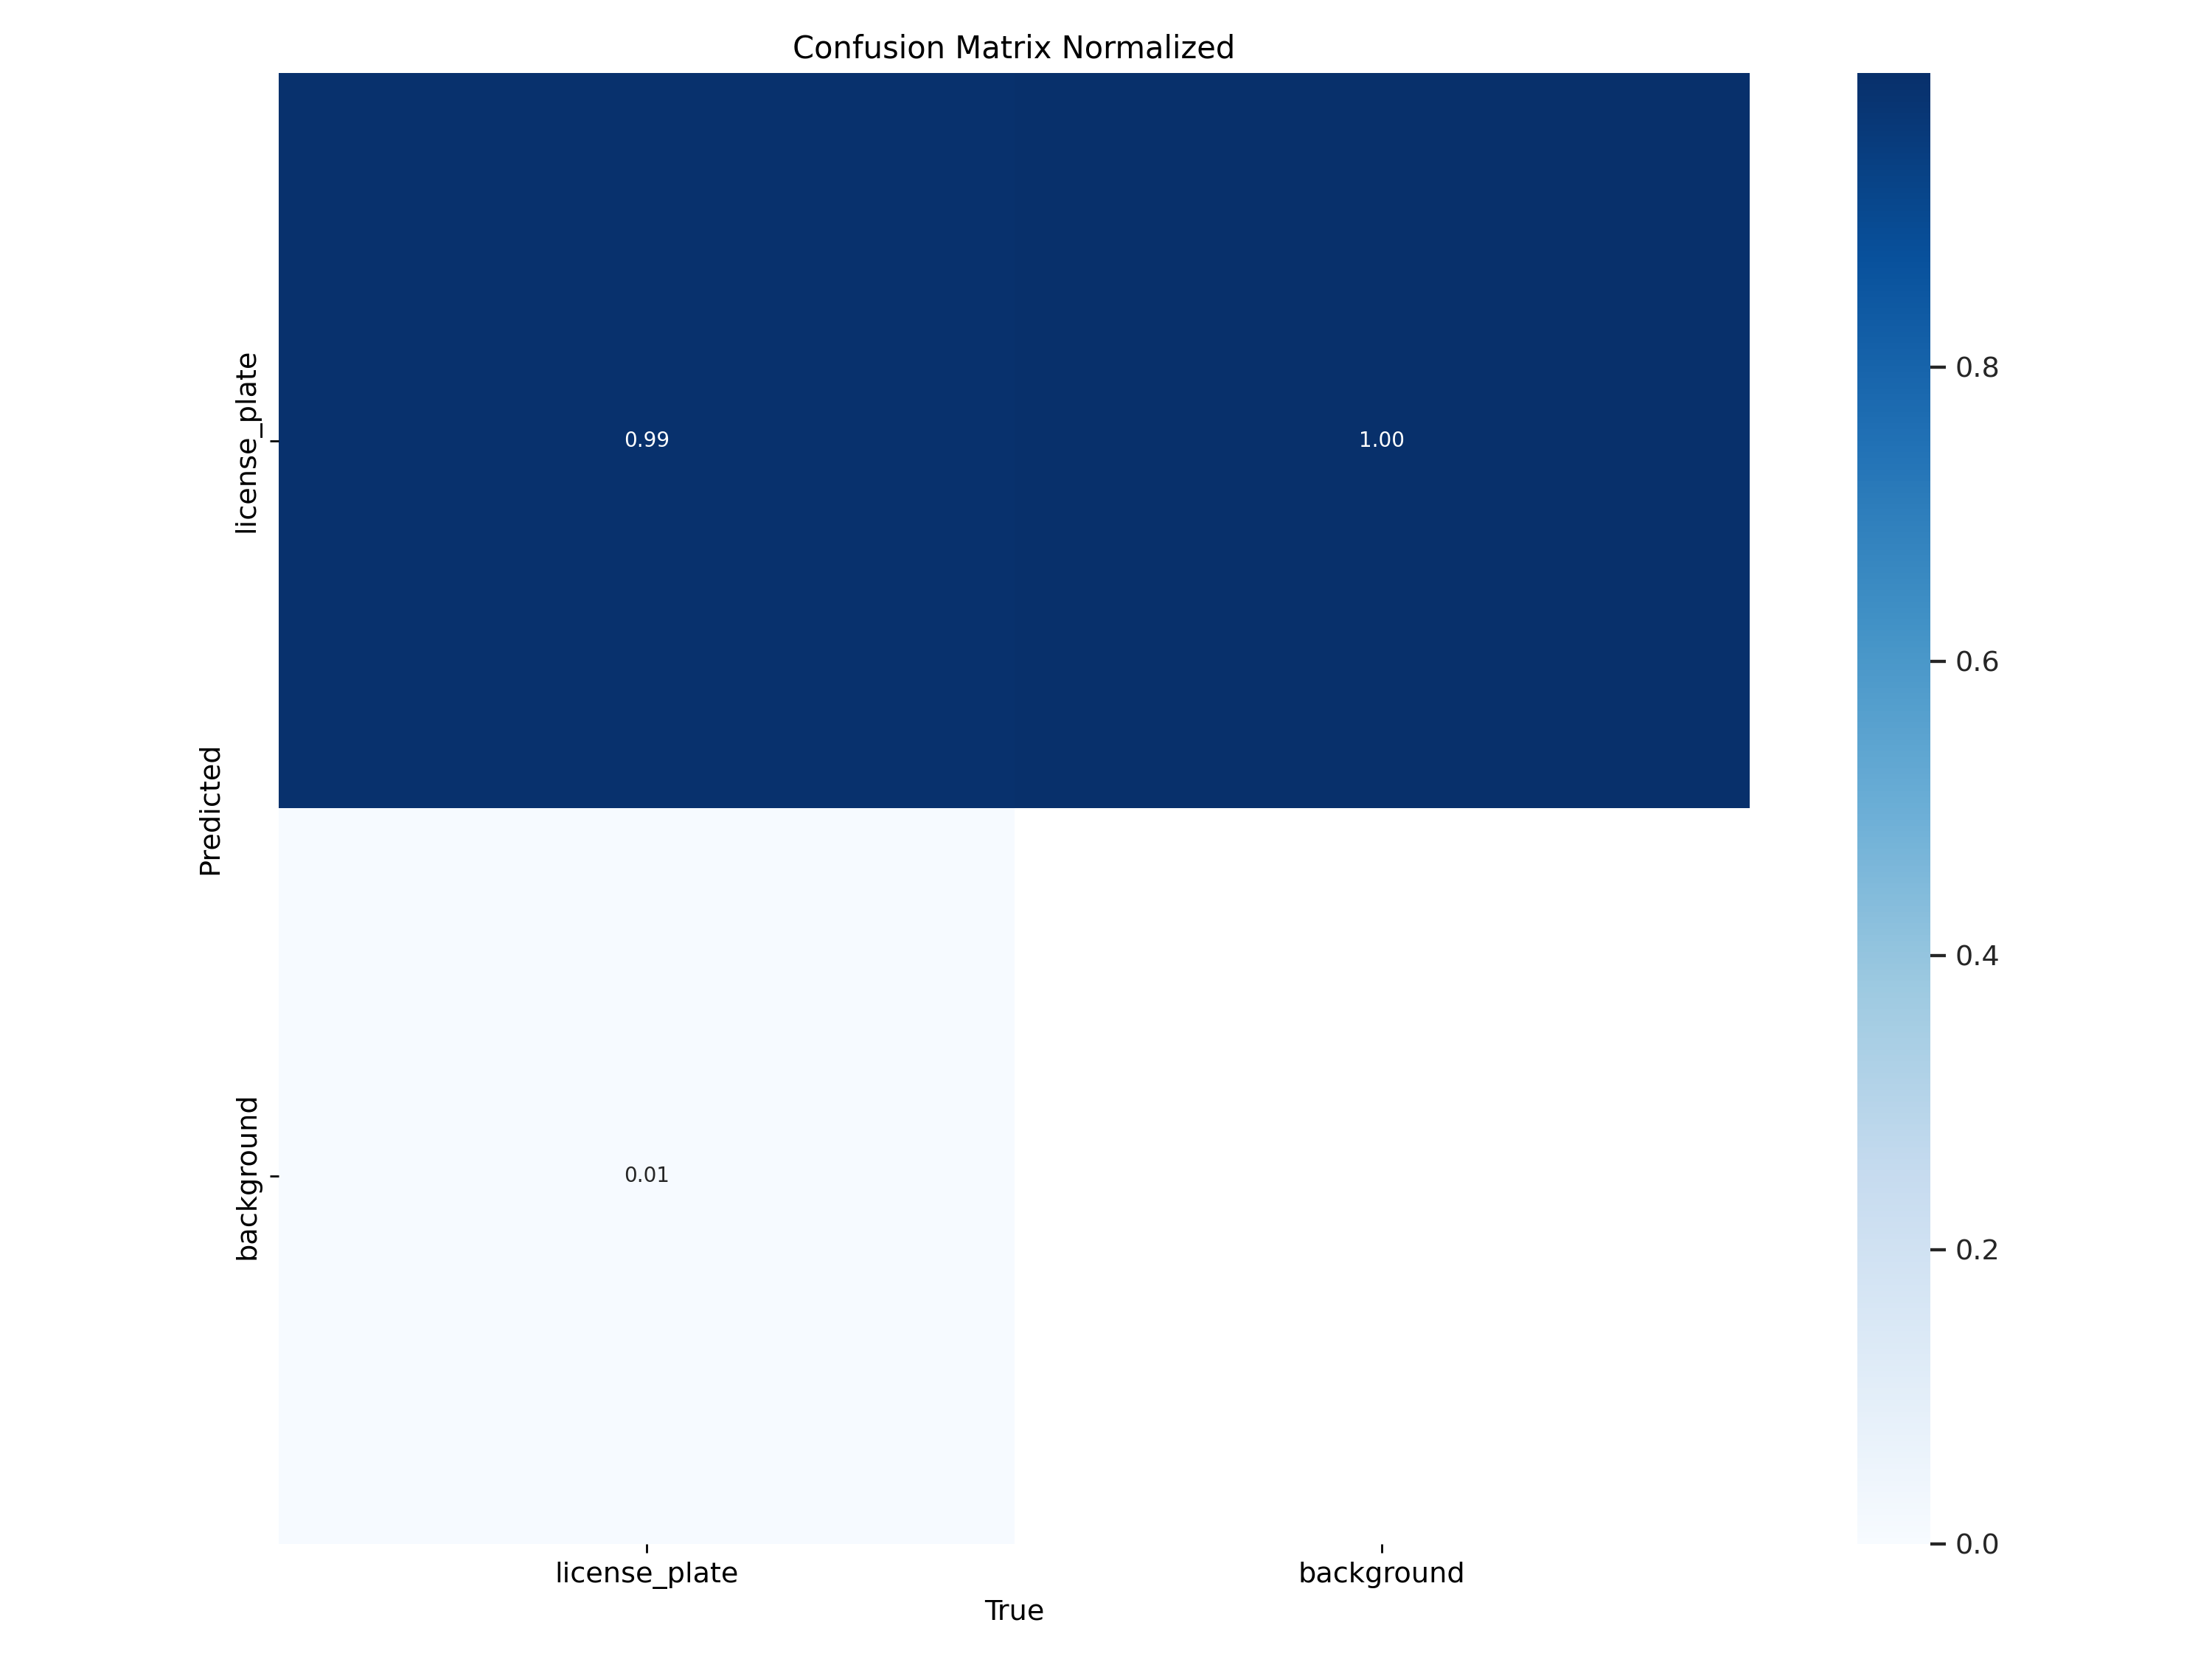

In [7]:
Image(filename='/content/confusion_matrix_normalized.png')

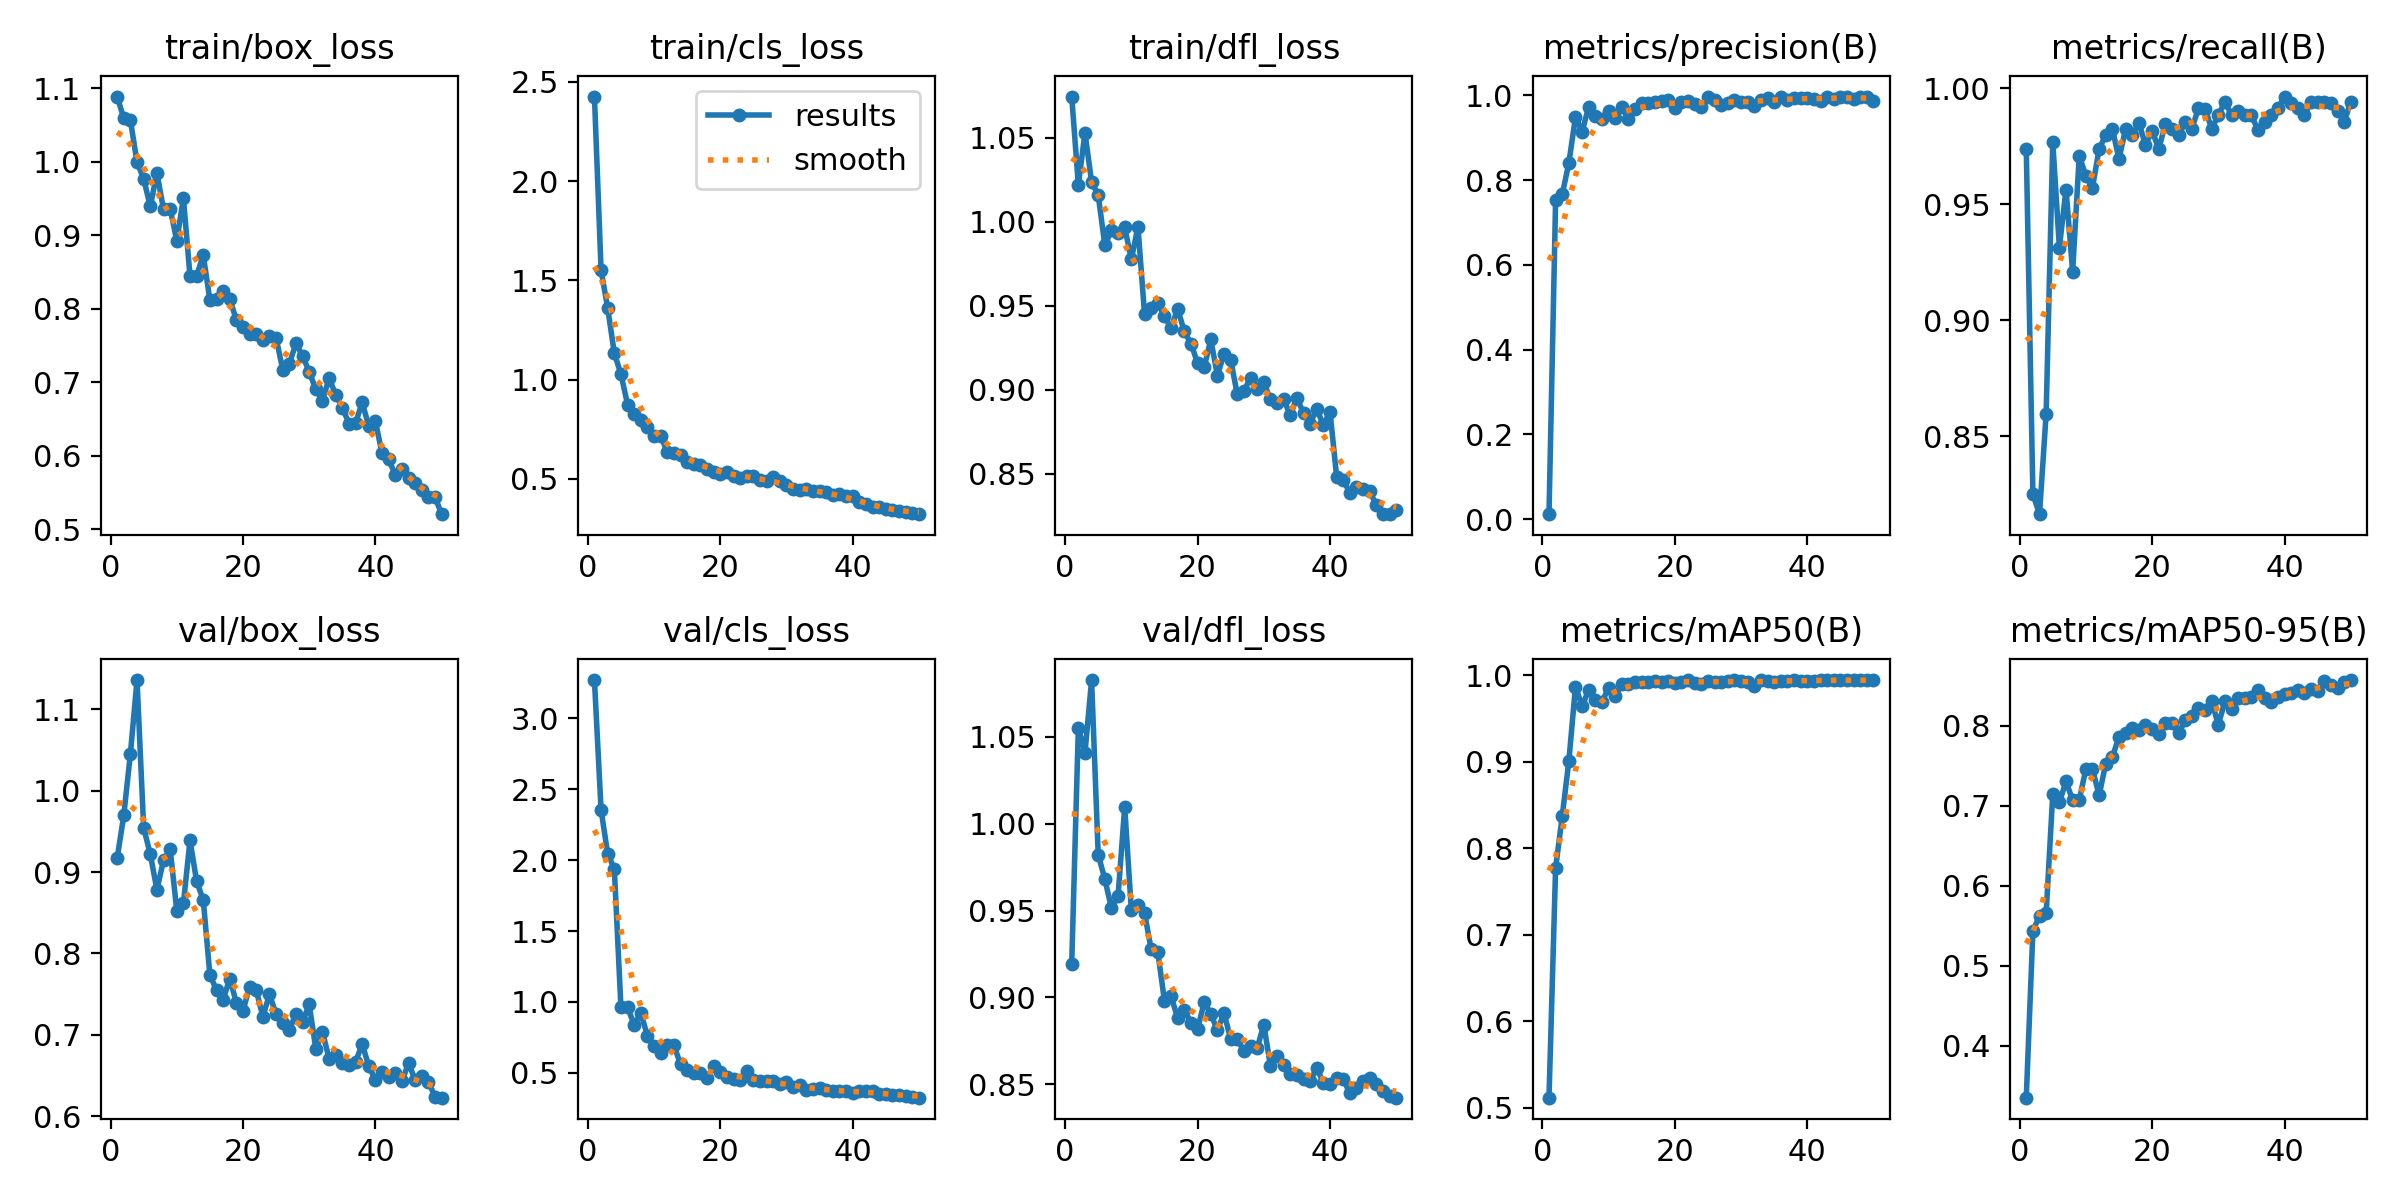

In [8]:
Image(filename='/content/results.png')

In [30]:
import pandas as pd

# Path to results.csv (YOLO saves it automatically)
results_path = "/content/runs/detect/train/results.csv"  # Adjust the path if needed

# Load the training results
df = pd.read_csv(results_path)

# Display the last row (final metrics after training)
final_metrics = df.iloc[-1]
print("Final Training Metrics:")
print(final_metrics)


Final Training Metrics:
epoch                      50.00000
time                    10162.10000
train/box_loss              0.52066
train/cls_loss              0.32117
train/dfl_loss              0.82820
metrics/precision(B)        0.98765
metrics/recall(B)           0.99417
metrics/mAP50(B)            0.99421
metrics/mAP50-95(B)         0.85724
val/box_loss                0.62284
val/cls_loss                0.32477
val/dfl_loss                0.84232
lr/pg0                      0.00006
lr/pg1                      0.00006
lr/pg2                      0.00006
Name: 49, dtype: float64


#Make prediction

In [22]:
!yolo task=detect mode=predict conf=0.25 save=True model='best.pt' source='car-ind-number-plate.jpeg'

Ultralytics 8.3.76 🚀 Python-3.11.11 torch-2.5.1+cu124 CPU (Intel Xeon 2.20GHz)
YOLO11n summary (fused): 100 layers, 2,582,347 parameters, 0 gradients, 6.3 GFLOPs

image 1/1 /content/car-ind-number-plate.jpeg: 480x640 1 license_plate, 181.0ms
Speed: 14.3ms preprocess, 181.0ms inference, 27.8ms postprocess per image at shape (1, 3, 480, 640)
Results saved to runs/detect/predict
💡 Learn more at https://docs.ultralytics.com/modes/predict


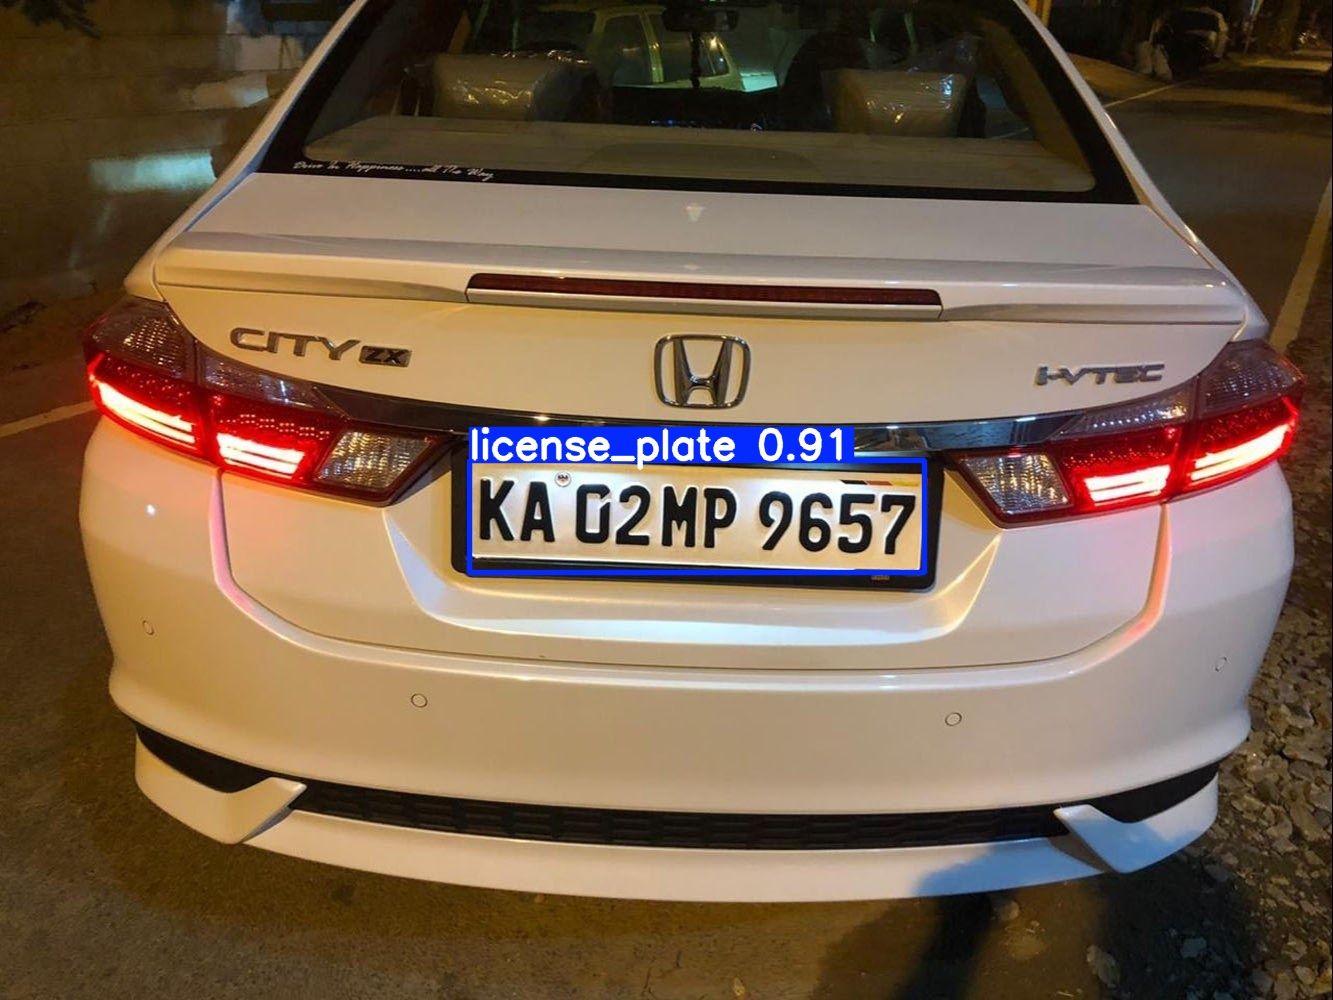

In [23]:
from IPython.display import Image
Image(filename='/content/runs/detect/predict/car-ind-number-plate.jpg')

#EasyOCR

In [24]:
!pip install easyocr

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.9/2.9 MB 44.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 422.9/422.9 kB 36.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 969.6/969.6 kB 52.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 286.6/286.6 kB 27.3 MB/s eta 0:00:00



0: 480x640 1 license_plate, 178.6ms
Speed: 4.7ms preprocess, 178.6ms inference, 1.9ms postprocess per image at shape (1, 3, 480, 640)


Progress: |██████████████████████████████████████████████████| 100.0% Complete

Progress: |██████████████████████████████████████████████████| 100.0% CompleteLicense Plate Text: KA G2MP 9657


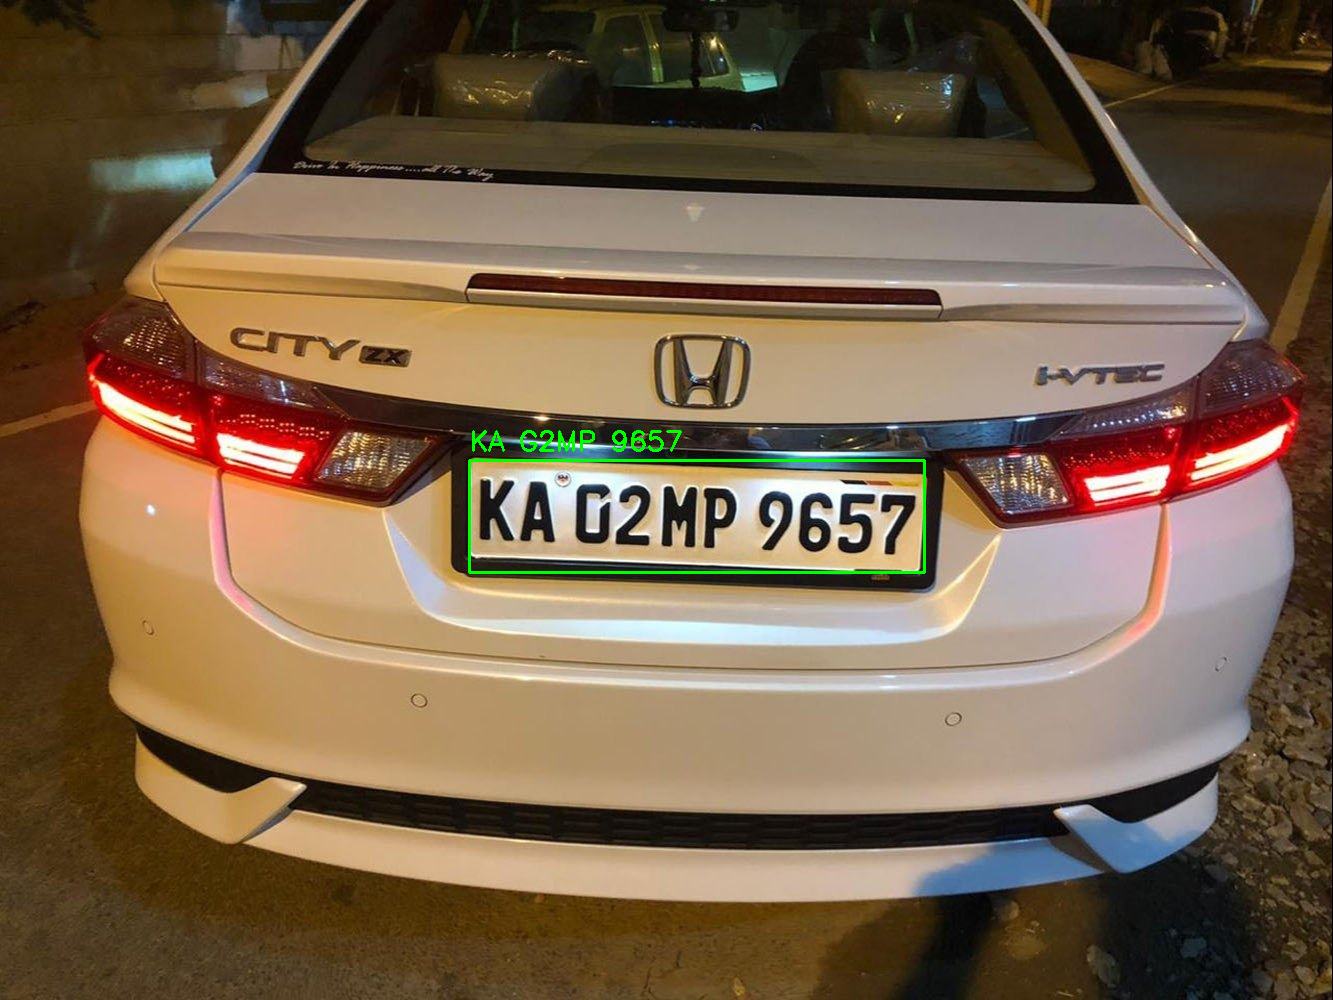

In [25]:
import cv2
import torch
import easyocr
from ultralytics import YOLO  # YOLOv11 model
from google.colab.patches import cv2_imshow
# Load YOLOv11 model
model = YOLO("/content/best.pt")  # Use your trained YOLOv11 model

# Load the image
image_path = "/content/car-ind-number-plate.jpeg"
image = cv2.imread(image_path)

# Run YOLO detection
results = model(image)

# Initialize EasyOCR reader
reader = easyocr.Reader(['en'])

# Process each detected object
for result in results:
    boxes = result.boxes  # Get bounding boxes

    for box in boxes:
        x1, y1, x2, y2 = map(int, box.xyxy[0])  # Get coordinates

        # Crop the detected license plate
        license_plate = image[y1:y2, x1:x2]

        # Convert to grayscale (optional for better OCR accuracy)
        gray_plate = cv2.cvtColor(license_plate, cv2.COLOR_BGR2GRAY)

        # Run OCR on the cropped plate
        text_results = reader.readtext(gray_plate)

        # Extract text from OCR result
        extracted_text = " ".join([text[1] for text in text_results])

        print(f"License Plate Text: {extracted_text}")

        # Draw the bounding box and text on the image
        cv2.rectangle(image, (x1, y1), (x2, y2), (0, 255, 0), 2)
        cv2.putText(image, extracted_text, (x1, y1 - 10), cv2.FONT_HERSHEY_SIMPLEX, 0.9, (0, 255, 0), 2)

# Save or display the output image
cv2_imshow(image)
cv2.imwrite("output.jpg", image)
cv2.waitKey(0)
cv2.destroyAllWindows()


#Code to upload to excel sheet

In [26]:
!pip install openpyxl


0: 480x640 1 license_plate, 145.1ms
Speed: 7.9ms preprocess, 145.1ms inference, 1.0ms postprocess per image at shape (1, 3, 480, 640)


License Plate Text: KA G2MP 9657


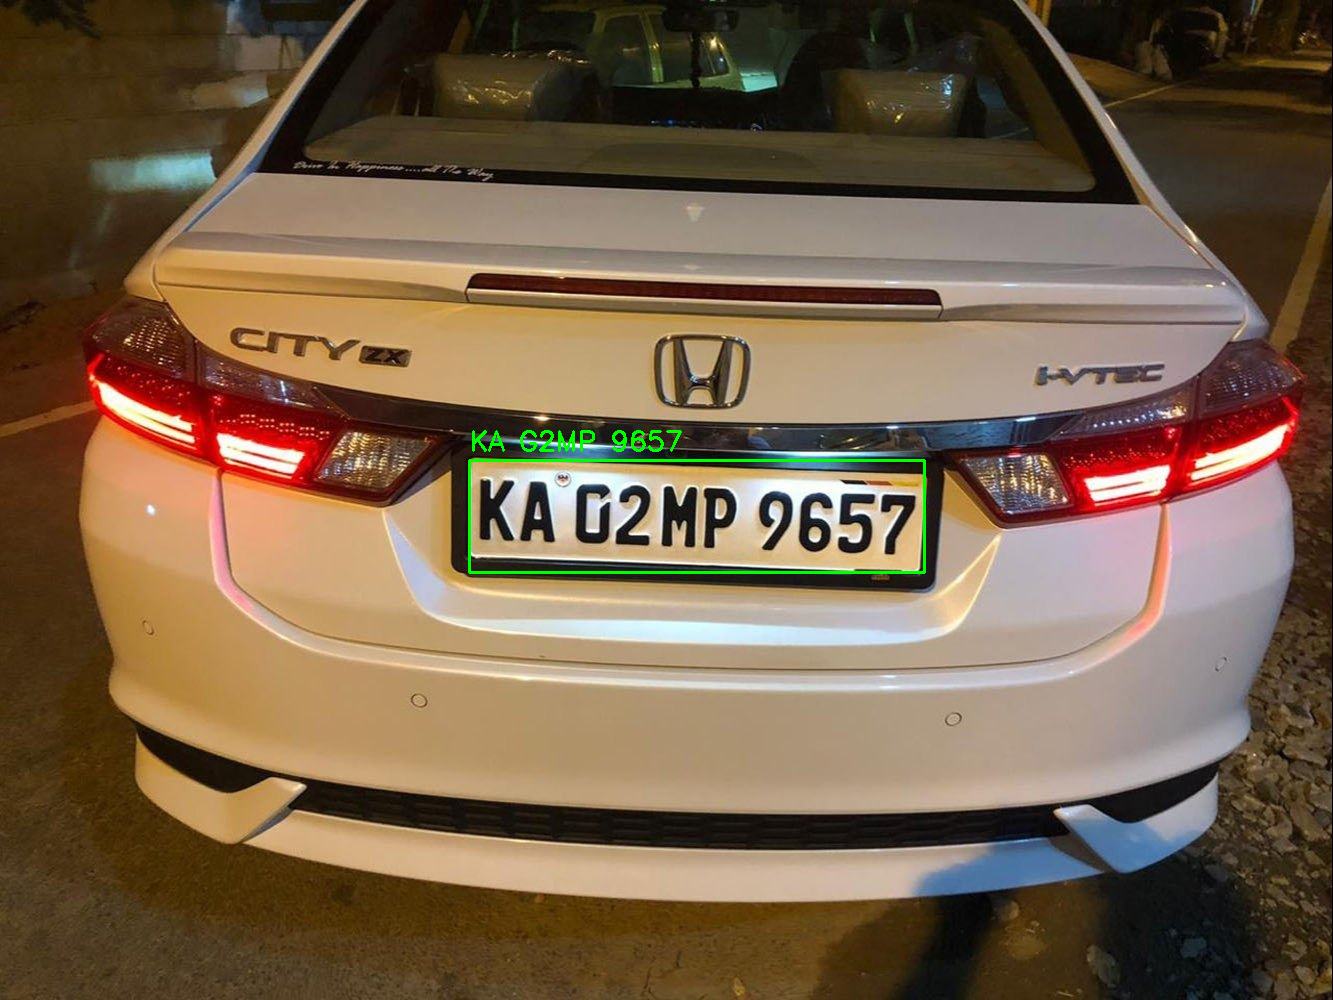

In [27]:
import cv2
import torch
import easyocr
import pandas as pd
from openpyxl import load_workbook
from ultralytics import YOLO
from google.colab.patches import cv2_imshow
# Load YOLOv11 model
model = YOLO("/content/best.pt")  # Replace with your model path

# Load the image
image_path = "/content/car-ind-number-plate.jpeg"
image = cv2.imread(image_path)

# Run YOLO detection
results = model(image)

# Initialize EasyOCR reader
reader = easyocr.Reader(['en'])

# Excel file to store license plate numbers
excel_file = "license_plates.xlsx"

# List to store extracted license plate texts
plate_numbers = []

# Process each detected object
for result in results:
    boxes = result.boxes  # Get bounding boxes

    for box in boxes:
        x1, y1, x2, y2 = map(int, box.xyxy[0])  # Get coordinates

        # Crop the detected license plate
        license_plate = image[y1:y2, x1:x2]

        # Convert to grayscale (optional for better OCR accuracy)
        gray_plate = cv2.cvtColor(license_plate, cv2.COLOR_BGR2GRAY)

        # Run OCR on the cropped plate
        text_results = reader.readtext(gray_plate)

        # Extract text from OCR result
        extracted_text = " ".join([text[1] for text in text_results])
        print(f"License Plate Text: {extracted_text}")

        # Save extracted text to list
        plate_numbers.append([extracted_text])

        # Draw bounding box and text on image
        cv2.rectangle(image, (x1, y1), (x2, y2), (0, 255, 0), 2)
        cv2.putText(image, extracted_text, (x1, y1 - 10), cv2.FONT_HERSHEY_SIMPLEX, 0.9, (0, 255, 0), 2)

# Save or display the output image
cv2_imshow(image)
cv2.imwrite("output.jpg", image)
cv2.waitKey(0)
cv2.destroyAllWindows()




In [28]:
# Save to Excel
df = pd.DataFrame(plate_numbers, columns=["License Plate"])

# Check if file exists and update it
try:
    existing_df = pd.read_excel(excel_file)
    df = pd.concat([existing_df, df], ignore_index=True)  # Append new data
except FileNotFoundError:
    pass  # If file doesn't exist, create a new one

df.to_excel(excel_file, index=False)  # Save to Excel
print(f"License plate numbers saved to {excel_file}")

License plate numbers saved to license_plates.xlsx


#Checking if the number plate is in the excel


0: 384x640 1 license_plate, 137.8ms
Speed: 7.9ms preprocess, 137.8ms inference, 1.1ms postprocess per image at shape (1, 3, 384, 640)


Detected License Plate: MH 14 TC 206 AA
❌ License Plate MH 14 TC 206 AA is NOT in the database.


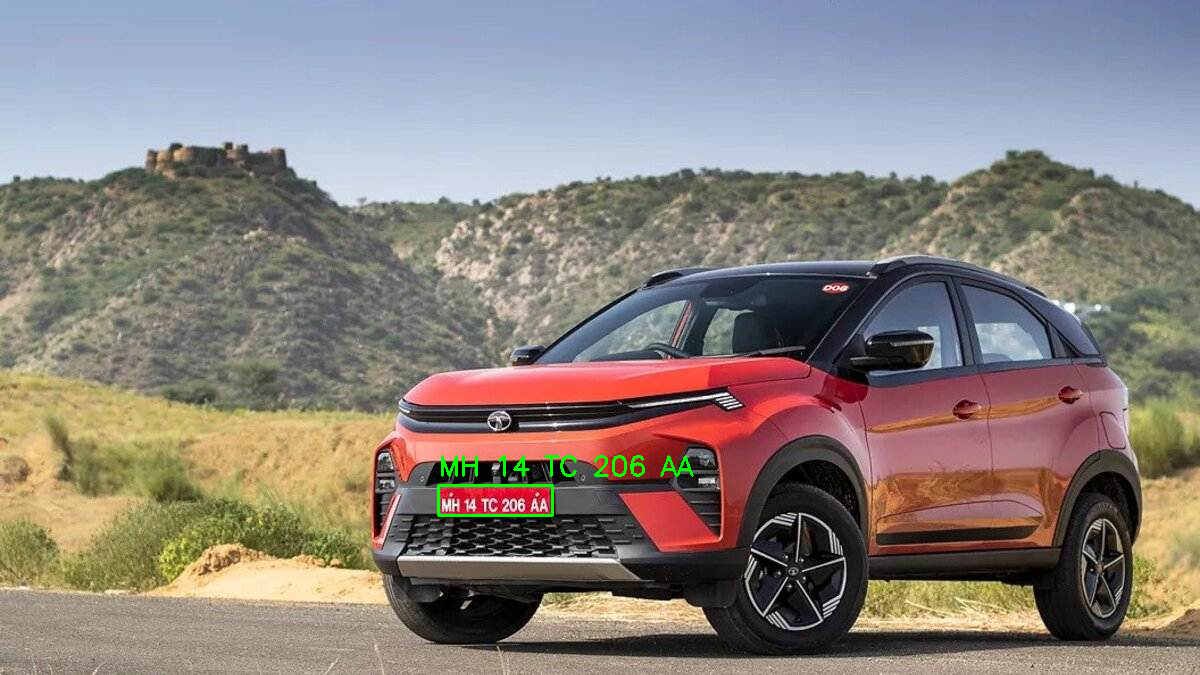

In [29]:
import cv2
import torch
import easyocr
import pandas as pd
from ultralytics import YOLO
from google.colab.patches import cv2_imshow
# Load YOLOv11 model
model = YOLO("/content/best.pt")  # Replace with your trained YOLOv11 model path

# Load the image
image_path = "/content/new-Tata-Nexon.jpg"  # Replace with your test image
image = cv2.imread(image_path)

# Run YOLO detection
results = model(image)

# Initialize EasyOCR reader
reader = easyocr.Reader(['en'])

# Path to the Excel file
excel_file = "/content/license_plates.xlsx"

# Read the existing Excel file
try:
    existing_df = pd.read_excel(excel_file)
    existing_plates = existing_df["License Plate"].astype(str).tolist()  # Convert to list
except FileNotFoundError:
    existing_plates = []  # If file doesn't exist, assume empty list

# Process each detected license plate
found_plates = []

for result in results:
    boxes = result.boxes  # Get bounding boxes

    for box in boxes:
        x1, y1, x2, y2 = map(int, box.xyxy[0])  # Get coordinates

        # Crop the detected license plate
        license_plate = image[y1:y2, x1:x2]

        # Convert to grayscale (optional for better OCR accuracy)
        gray_plate = cv2.cvtColor(license_plate, cv2.COLOR_BGR2GRAY)

        # Run OCR on the cropped plate
        text_results = reader.readtext(gray_plate)

        # Extract text from OCR result
        extracted_text = " ".join([text[1] for text in text_results])
        extracted_text = extracted_text.strip().upper()  # Normalize text

        print(f"Detected License Plate: {extracted_text}")

        # Check if the detected license plate is in the Excel file
        if extracted_text in existing_plates:
            print(f"✅ License Plate {extracted_text} is in the database.")
            found_plates.append(extracted_text)
        else:
            print(f"❌ License Plate {extracted_text} is NOT in the database.")

        # Draw bounding box and text on image
        cv2.rectangle(image, (x1, y1), (x2, y2), (0, 255, 0), 2)
        cv2.putText(image, extracted_text, (x1, y1 - 10), cv2.FONT_HERSHEY_SIMPLEX, 0.9, (0, 255, 0), 2)

# Save or display the output image
cv2_imshow(image)
cv2.imwrite("output.jpg", image)
cv2.waitKey(0)
cv2.destroyAllWindows()
